In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
sns.set()
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('segmentation data.csv',index_col = 0)
df.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
ID,,,,,,,
100000001,0,0,67,2,124670,1,2
100000002,1,1,22,1,150773,1,2
100000003,0,0,49,1,89210,0,0
100000004,0,0,45,1,171565,1,1
100000005,0,0,53,1,149031,1,1


In [ ]:
df.describe()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [ ]:
df.corr()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
Sex,1.000000,0.566511,-0.182885,0.244838,-0.195146,-0.202491,-0.300803
Marital status,0.566511,1.000000,-0.213178,0.374017,-0.073528,-0.029490,-0.097041
Age,-0.182885,-0.213178,1.000000,0.654605,0.340610,0.108388,0.119751
Education,0.244838,0.374017,0.654605,1.000000,0.233459,0.064524,0.034732
Income,-0.195146,-0.073528,0.340610,0.233459,1.000000,0.680357,0.490881
Occupation,-0.202491,-0.029490,0.108388,0.064524,0.680357,1.000000,0.571795
Settlement size,-0.300803,-0.097041,0.119751,0.034732,0.490881,0.571795,1.000000


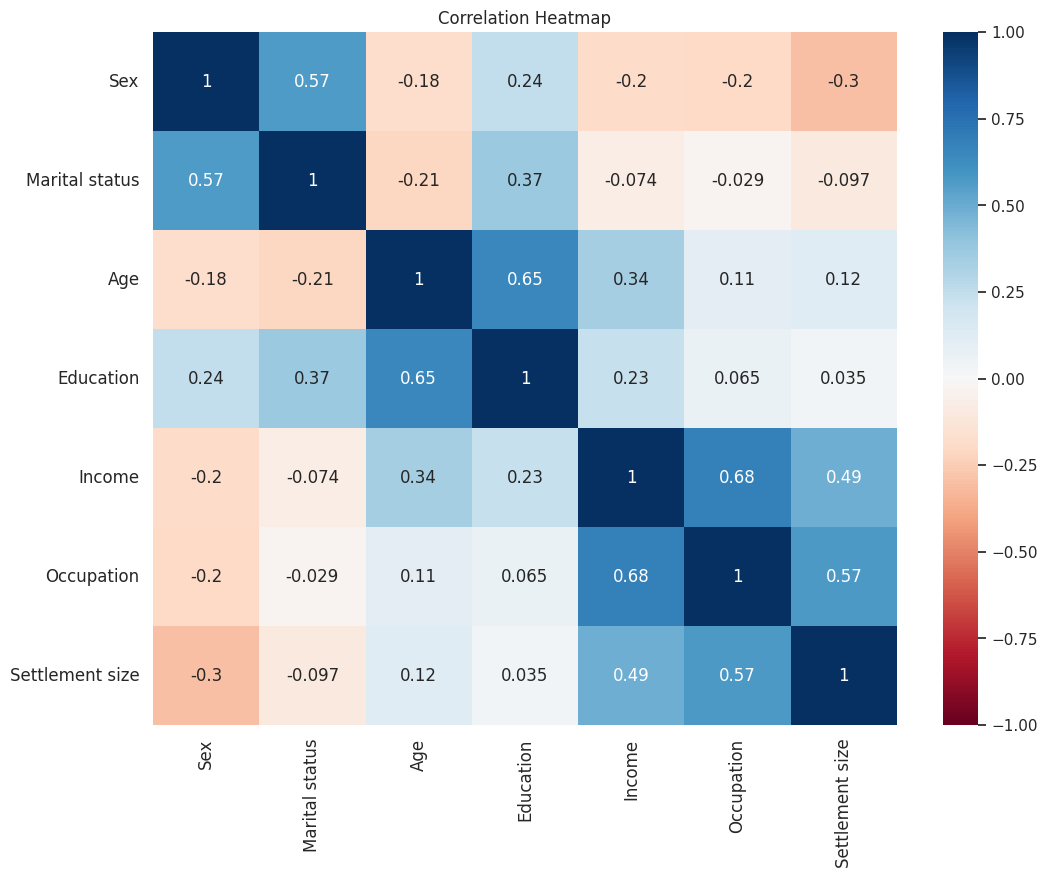

In [ ]:
plt.figure(figsize=(12,9))
s = sns.heatmap(df.corr(),annot=True,cmap='RdBu',vmin=-1,vmax=1)
s.set_yticklabels(s.get_yticklabels(),rotation=0,fontsize=12)
s.set_xticklabels(s.get_yticklabels(),rotation=90,fontsize=12)
plt.title('Correlation Heatmap')
plt.show()

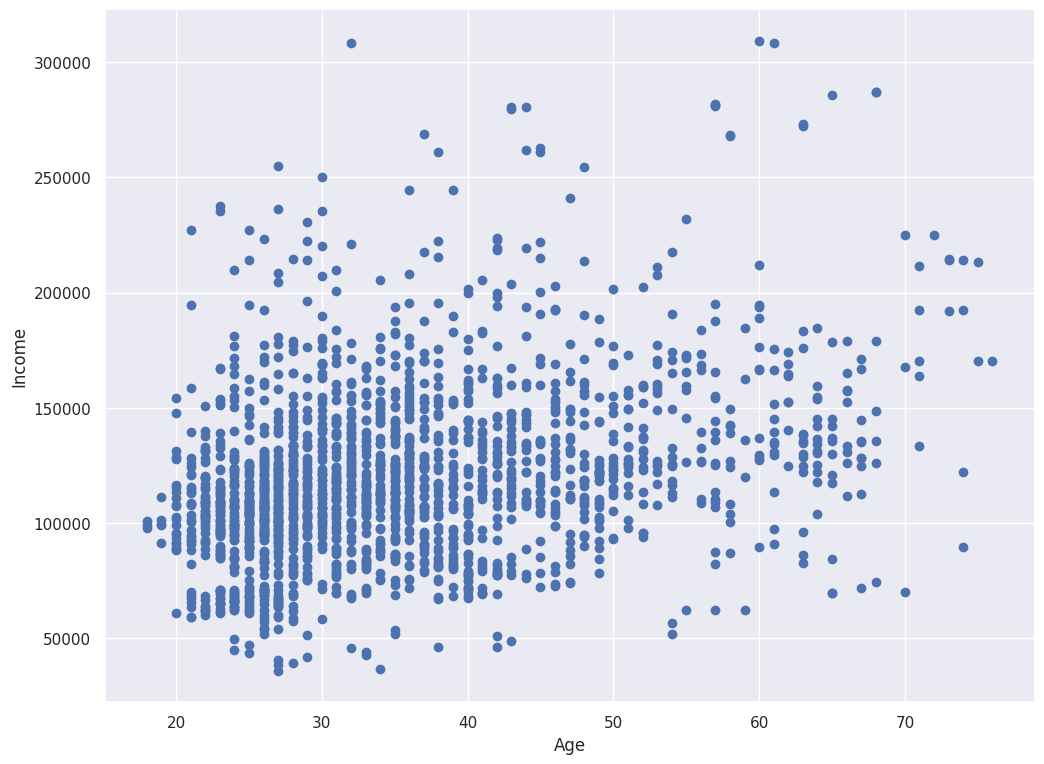

In [ ]:
plt.figure(figsize=(12,9))
plt.scatter(df['Age'],df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

# Feature Scaling (StandardScaler) -
Because in this dataset, age is in maximum 2 digits (e.g., 25 to 70), and income is in thousands/lakhs (e.g., 30,000 to 3,00,000).

Hierarchical clustering works on Euclidean Distance. If we don't scale, the computer will think that a difference of 10,000 in income is much bigger than a difference of 10 years in age, and the model will create clusters based on income alone.

In [ ]:
scaler = StandardScaler()
scaled_df  = scaler.fit_transform(df)
scaled_df

array([[-0.91739884, -0.99302433,  2.65361447, ...,  0.09752361,
         0.29682303,  1.552326  ],
       [ 1.09003844,  1.00702467, -1.18713209, ...,  0.78265438,
         0.29682303,  1.552326  ],
       [-0.91739884, -0.99302433,  1.11731585, ..., -0.83320224,
        -1.26952539, -0.90972951],
       ...,
       [-0.91739884, -0.99302433, -0.41898277, ..., -0.90695688,
        -1.26952539, -0.90972951],
       [ 1.09003844,  1.00702467, -1.01643224, ..., -0.60332923,
        -1.26952539, -0.90972951],
       [-0.91739884, -0.99302433, -0.93108232, ..., -1.3789866 ,
        -1.26952539, -0.90972951]])

# Hierarchical Clustering

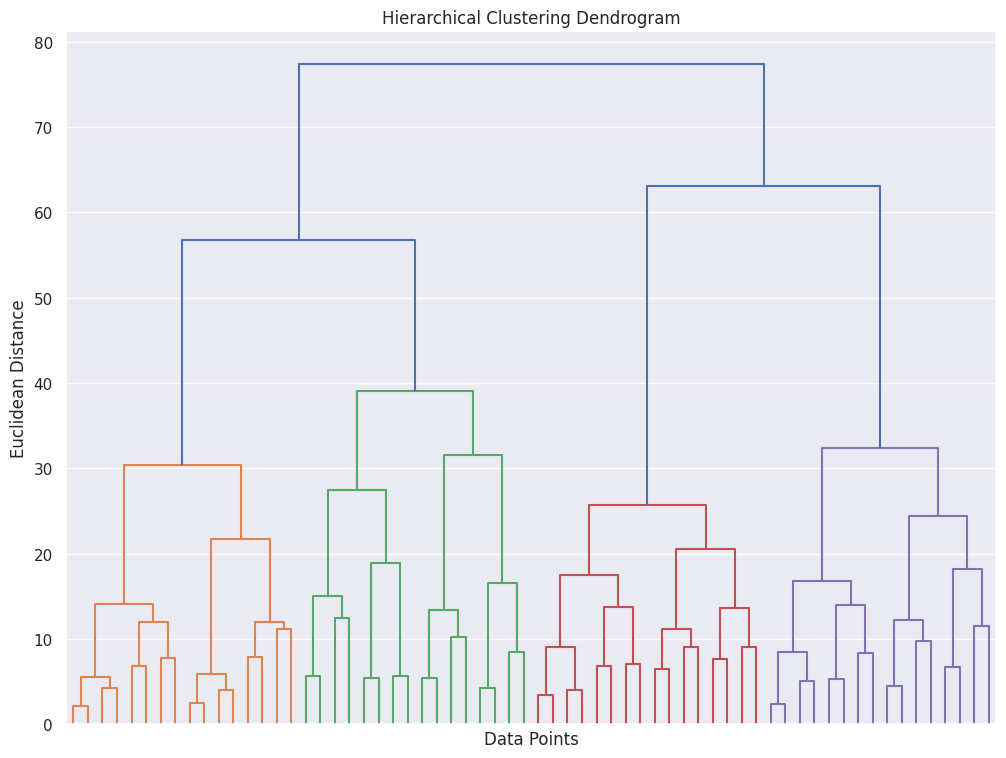

In [ ]:
hier_clust = linkage(scaled_df, method='ward')
plt.figure(figsize=(12,9))
# dendrogram(hier_clust,leaf_rotation=90)                      # En dono lines ka fark dekhna
dendrogram(hier_clust,truncate_mode = 'level',p=5,show_leaf_counts=False,no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')                          # ya observations b name de sake ese
plt.ylabel('Euclidean Distance')
plt.show()

# Step 3: Clusters Profile Analysis (Business Meaning)
The real purpose of clustering is to understand which cluster contains which type of people so let's see -


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Model design aur fitment
hc = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(scaled_df)

df['Cluster'] = y_hc                    # Added 'Cluster' in real Dataset


In [ ]:
# Har cluster ki demographic characteristics check karne ke liye
cluster_profile = df.groupby('Cluster').mean()
print(cluster_profile)


              Sex  Marital status        Age  Education         Income  \
Cluster                                                                  
0        0.640986        0.445300  34.583975   0.992296   90807.328197   
1        0.000000        0.000000  36.813472   0.673575  137369.343696   
2        0.497925        0.717842  54.593361   2.120332  163924.684647   
3        0.711864        1.000000  28.062147   1.000000  120399.591337   

         Occupation  Settlement size  
Cluster                               
0          0.101695         0.023112  
1          1.176166         1.245250  
2          1.257261         1.219917  
3          1.075330         0.843691  


# Segment Analysis :-

# Cluster 0: "The Budget-Conscious Young Starters"

* Demographics: This group is majority female (Sex: 0.64) with less than half being married (Marital Status: 0.44). They are relatively young, with an average age of ~35.
* Socio-Economic Status: They have the lowest occupation score (0.10), indicating they are mostly students, unemployed, or working entry-level jobs.
* Income & Location: They have the lowest income (~$90,807) and live almost exclusively in small towns or rural areas (Settlement size: 0.02).
* **Business Strategy:** Target them with budget-friendly products, discounts, value-for-money deals, and entry-level services.

## Cluster 1: "The Well-Off Single Professionals"

* Demographics: This group consists entirely of single males (Sex: 0.00, Marital status: 0.00) with an average age of ~37.
* Socio-Economic Status: They are highly career-oriented, holding good management or professional jobs (Occupation: 1.17).
* Income & Location: They have a high disposable income (~$137,369) and live in major metropolitan cities (Settlement size: 1.24).
* **Business Strategy:** Since they are affluent and single, they are ideal targets for premium gadgets, lifestyle products, travel, and personal luxury goods.

## Cluster 2: "The Wealthy Elite / Seniors"

* Demographics: Balanced gender mix (Sex: 0.49) where the majority are married (0.71). This is the oldest segment in your data, averaging ~55 years old.
* Socio-Economic Status: They are the most highly educated group (Education: 2.12) and hold top-tier executive or business positions (Occupation: 1.25).
* Income & Location: This is wealthiest segment with the highest average income (~$163,924), residing in big cities (Settlement size: 1.21).
* **Business Strategy:** This is VVIP cluster. Focus on premium/luxury marketing, wealth management, health insurance, retirement planning, and high-end quality services where price is not a barrier.

## Cluster 3: "The Affluent Young Couples"

* Demographics: This segment is predominantly female (Sex: 0.71) and 100% married (Marital status: 1.00). It is also the youngest segment in data, averaging ~28 years old.
* Socio-Economic Status: Despite being very young, they have already secured good professional jobs (Occupation: 1.07).
* Income & Location: They earn a very strong income for their age (~$120,399) and live in mid-to-large-sized cities (Settlement size: 0.84).
* **Business Strategy:** These are young households starting their families. Target them with home appliances, real estate, car loans, family vacation packages, and child/parenting products.
